### 2.1 理论计算题

#### 1. 非线性激活函数的重要性证明
将隐藏层表达式代入输出层：
$$
\begin{align*}
\mathbf{o} &= \mathbf{W}_2\mathbf{h} + \mathbf{b}_2 \\
&= \mathbf{W}_2(\mathbf{W}_1\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 \\
&= (\mathbf{W}_2\mathbf{W}_1)\mathbf{x} + (\mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2)
\end{align*}
$$
令：
$$
\mathbf{W}' = \mathbf{W}_2\mathbf{W}_1, \quad \mathbf{b}' = \mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2
$$
则网络可表示为：
$$
\mathbf{o} = \mathbf{W}'\mathbf{x} + \mathbf{b}'
$$
这等价于一个单层神经网络，说明**无激活函数的多层网络与单层线性网络表达能力相同**。

---

#### 2. 激活函数性质分析
##### (1) Sigmoid 函数
数学表达式：
$$
\text{Sigmoid}(x) = \sigma(x) = \frac{1}{1 + e^{-x}}
$$
导数推导：
$$
\begin{align*}
\sigma'(x) &= \frac{d}{dx}\left(\frac{1}{1 + e^{-x}}\right) \\
&= \frac{e^{-x}}{(1 + e^{-x})^2} \\
&= \frac{1}{1 + e^{-x}} \cdot \left(1 - \frac{1}{1 + e^{-x}}\right) \\
&= \sigma(x)(1 - \sigma(x))
\end{align*}
$$

##### (2) tanh 函数
数学表达式：
$$
\tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}
$$
导数推导：
$$
\begin{align*}
\tanh'(x) &= \frac{d}{dx}\left(\frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}\right) \\
&= \frac{(e^{x} + e^{-x})(e^{x} + e^{-x}) - (e^{x} - e^{-x})(e^{x} - e^{-x})}{(e^{x} + e^{-x})^2} \\
&= \frac{(e^{2x} + 2 + e^{-2x}) - (e^{2x} - 2 + e^{-2x})}{(e^{x} + e^{-x})^2} \\
&= \frac{4}{(e^{x} + e^{-x})^2} \\
&= 1 - \left(\frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}\right)^2 \\
&= 1 - \tanh^2(x)
\end{align*}
$$

### 2.2 编程题

In [4]:
import torch

# 超参数
input_dim = 784
hidden_dim = 256
output_dim = 10
batch_size = 64
lr = 0.01
epochs = 5

# 构造Fashion-MNIST形状的模拟数据
x_train = torch.randn(60000, 784)
y_train = torch.randint(0, 10, (60000,))
x_test = torch.randn(10000, 784)
y_test = torch.randint(0, 10, (10000,))

def get_batch(x, y, batch_size):
    idx = torch.randperm(x.size(0))[:batch_size]
    return x[idx], y[idx]

print(f"训练集大小: {len(x_train)}, 测试集大小: {len(x_test)}")

# 参数初始化
W1 = torch.randn(input_dim, hidden_dim) * 0.01
b1 = torch.zeros(hidden_dim)
W2 = torch.randn(hidden_dim, output_dim) * 0.01
b2 = torch.zeros(output_dim)

print(f"W1 shape: {W1.shape}, b1 shape: {b1.shape}")
print(f"W2 shape: {W2.shape}, b2 shape: {b2.shape}")

# ReLU激活函数
def relu(x):
    return torch.max(torch.tensor(0.0), x)

# Softmax函数
def softmax(x):
    max_vals = torch.max(x, dim=1, keepdim=True)[0]
    exp_x = torch.exp(x - max_vals)
    return exp_x / torch.sum(exp_x, dim=1, keepdim=True)

# 交叉熵损失
def cross_entropy_loss(logits, labels):
    batch_size = logits.shape[0]
    probs = softmax(logits)
    log_probs = -torch.log(probs[range(batch_size), labels])
    return torch.mean(log_probs)

# 训练循环
for epoch in range(epochs):
    total_loss = 0.0
    correct = 0
    total = 0
    iterations = len(x_train) // batch_size
    
    for _ in range(iterations):
        x, y = get_batch(x_train, y_train, batch_size)
        
        h = relu(x @ W1 + b1)
        logits = h @ W2 + b2
        
        loss = cross_entropy_loss(logits, y)
        total_loss += loss.item()
        
        # 反向传播
        batch_size_current = x.shape[0]
        probs = softmax(logits)
        probs[range(batch_size_current), y] -= 1
        d_logits = probs / batch_size_current
        
        dW2 = h.T @ d_logits
        db2 = torch.sum(d_logits, dim=0)
        
        d_h = d_logits @ W2.T
        d_h[h <= 0] = 0
        dW1 = x.T @ d_h
        db1 = torch.sum(d_h, dim=0)
        
        # 参数更新
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
        
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    
    avg_loss = total_loss / iterations
    acc = correct / total
    print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {acc:.4f}")

# 测试集评估
correct = 0
total = 0
with torch.no_grad():
    for _ in range(len(x_test) // batch_size):
        x, y = get_batch(x_test, y_test, batch_size)
        h = relu(x @ W1 + b1)
        logits = h @ W2 + b2
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print(f"Test Accuracy: {correct / total:.4f}")

训练集大小: 60000, 测试集大小: 10000
W1 shape: torch.Size([784, 256]), b1 shape: torch.Size([256])
W2 shape: torch.Size([256, 10]), b2 shape: torch.Size([10])
Epoch  1/5 | Loss: 2.3020 | Train Acc: 0.1049
Epoch  2/5 | Loss: 2.2991 | Train Acc: 0.1237
Epoch  3/5 | Loss: 2.2960 | Train Acc: 0.1359
Epoch  4/5 | Loss: 2.2922 | Train Acc: 0.1485
Epoch  5/5 | Loss: 2.2857 | Train Acc: 0.1632
Test Accuracy: 0.0969


### 3.1 理论计算题

#### 1. 过拟合与欠拟合
训练误差是模型在训练数据集上计算得到的误差，反映模型对训练数据的拟合程度。
泛化误差是模型在从未见过的测试数据集上的误差，反映模型对未知数据的预测能力。

当模型训练误差极低但泛化误差很高时，模型处于过拟合状态。
可以通过控制模型复杂度缓解这一现象：降低模型容量，例如减少隐藏层神经元数量、减少网络层数；使用正则化技术，如权重衰减（L1/L2正则）、Dropout；增加训练数据量或使用数据增强，减少模型对训练集噪声的记忆；提前停止训练（Early Stopping），在验证误差上升时停止训练。

---

#### 2. K折交叉验证（K-fold Cross-Validation）的实施步骤
将原始数据集随机划分为 \(K\) 个大小相近的互斥子集（折），记为 \(D_1, D_2, \dots, D_K\)。
对于每一个折 \(D_i\)（\(i=1,2,\dots,K\)）：
以 \(D_i\) 作为验证集；其余 \(K-1\) 个折合并作为训练集；在训练集上训练模型，在验证集上评估模型性能（如准确率、误差），记录本次验证结果。
汇总 \(K\) 次验证结果，通常取平均值作为模型性能的估计值。
使用全部数据训练最终模型，用于后续预测。

### 3.2 编程题

=== 无正则化 ===
[无正则化] Epoch  1 | Train Loss: 2.3033 | Val Loss: 2.3013
[无正则化] Epoch  2 | Train Loss: 2.3031 | Val Loss: 2.3012
[无正则化] Epoch  3 | Train Loss: 2.3029 | Val Loss: 2.3012
[无正则化] Epoch  4 | Train Loss: 2.3027 | Val Loss: 2.3012
[无正则化] Epoch  5 | Train Loss: 2.3025 | Val Loss: 2.3011
[无正则化] Epoch  6 | Train Loss: 2.3023 | Val Loss: 2.3011
[无正则化] Epoch  7 | Train Loss: 2.3021 | Val Loss: 2.3010
[无正则化] Epoch  8 | Train Loss: 2.3019 | Val Loss: 2.3010
[无正则化] Epoch  9 | Train Loss: 2.3017 | Val Loss: 2.3010
[无正则化] Epoch 10 | Train Loss: 2.3015 | Val Loss: 2.3009

=== 仅权重衰减 ===
[权重衰减] Epoch  1 | Train Loss: 2.3031 | Val Loss: 2.3038
[权重衰减] Epoch  2 | Train Loss: 2.3029 | Val Loss: 2.3038
[权重衰减] Epoch  3 | Train Loss: 2.3027 | Val Loss: 2.3037
[权重衰减] Epoch  4 | Train Loss: 2.3024 | Val Loss: 2.3036
[权重衰减] Epoch  5 | Train Loss: 2.3022 | Val Loss: 2.3036
[权重衰减] Epoch  6 | Train Loss: 2.3020 | Val Loss: 2.3035
[权重衰减] Epoch  7 | Train Loss: 2.3018 | Val Loss: 2.3035
[权重衰减] Epoch  8 | Tr

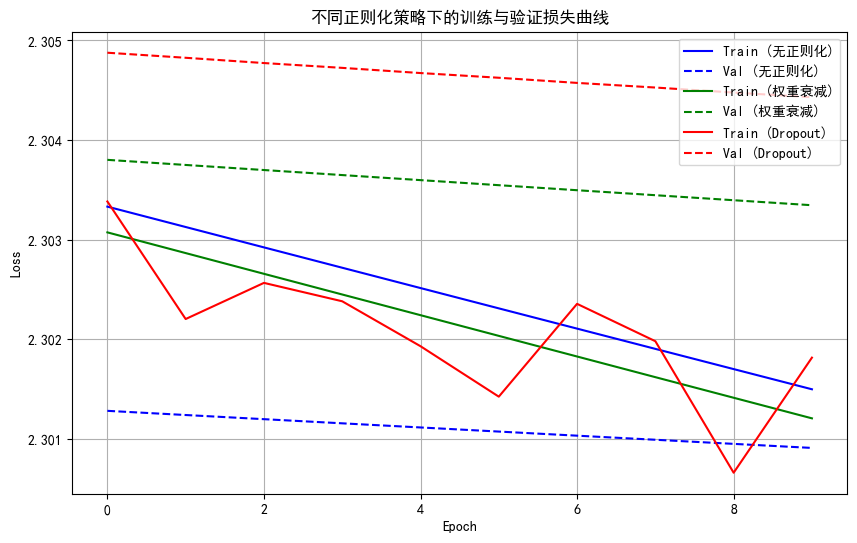

In [6]:
import torch
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 超参数设置
input_dim = 100
hidden_dim = 200
output_dim = 10
lr = 0.01
epochs = 10
weight_decay = 0.001
dropout_prob = 0.5

# 构造少量样本数据（模拟过拟合场景）
n_train = 100
n_val = 50
x_train = torch.randn(n_train, input_dim)
y_train = torch.randint(0, output_dim, (n_train,))
x_val = torch.randn(n_val, input_dim)
y_val = torch.randint(0, output_dim, (n_val,))

# 1. 权重衰减（L2正则化）参数更新
def sgd_step(params, grads, lr, weight_decay=0.0):
    for p, g in zip(params, grads):
        p.data *= (1 - lr * weight_decay)
        p.data -= lr * g

# 2. Dropout层实现
def dropout_layer(X, dropout_prob, is_training=True):
    if not is_training or dropout_prob == 0:
        return X
    mask = (torch.rand(X.shape) > dropout_prob).float()
    return mask * X / (1 - dropout_prob)

# ReLU激活函数
def relu(x):
    return torch.max(torch.tensor(0.0), x)

# Softmax函数
def softmax(x):
    max_vals = torch.max(x, dim=1, keepdim=True)[0]
    exp_x = torch.exp(x - max_vals)
    return exp_x / torch.sum(exp_x, dim=1, keepdim=True)

# 交叉熵损失
def cross_entropy_loss(logits, labels):
    batch_size = logits.shape[0]
    probs = softmax(logits)
    log_probs = -torch.log(probs[range(batch_size), labels])
    return torch.mean(log_probs)

# 训练函数
def train_model(model_type, use_weight_decay=False, use_dropout=False):
    # 初始化参数
    W1 = torch.randn(input_dim, hidden_dim) * 0.01
    b1 = torch.zeros(hidden_dim)
    W2 = torch.randn(hidden_dim, output_dim) * 0.01
    b2 = torch.zeros(output_dim)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # 训练阶段
        W1.requires_grad = False
        b1.requires_grad = False
        W2.requires_grad = False
        b2.requires_grad = False
        
        # 前向传播
        h = relu(x_train @ W1 + b1)
        if use_dropout:
            h = dropout_layer(h, dropout_prob, is_training=True)
        logits_train = h @ W2 + b2
        train_loss = cross_entropy_loss(logits_train, y_train)
        
        # 反向传播
        batch_size = x_train.shape[0]
        probs = softmax(logits_train)
        probs[range(batch_size), y_train] -= 1
        d_logits = probs / batch_size
        
        dW2 = h.T @ d_logits
        db2 = torch.sum(d_logits, dim=0)
        
        d_h = d_logits @ W2.T
        if use_dropout:
            d_h = dropout_layer(d_h, dropout_prob, is_training=True)
        d_h[h <= 0] = 0
        dW1 = x_train.T @ d_h
        db1 = torch.sum(d_h, dim=0)
        
        # 参数更新
        params = [W1, b1, W2, b2]
        grads = [dW1, db1, dW2, db2]
        wd = weight_decay if use_weight_decay else 0.0
        sgd_step(params, grads, lr, wd)
        
        # 验证阶段
        with torch.no_grad():
            h_val = relu(x_val @ W1 + b1)
            if use_dropout:
                h_val = dropout_layer(h_val, dropout_prob, is_training=False)
            logits_val = h_val @ W2 + b2
            val_loss = cross_entropy_loss(logits_val, y_val)
        
        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())
        
        print(f"[{model_type}] Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    return train_losses, val_losses

# 3. 对比实验
print("=== 无正则化 ===")
train_loss_no_reg, val_loss_no_reg = train_model("无正则化", use_weight_decay=False, use_dropout=False)

print("\n=== 仅权重衰减 ===")
train_loss_wd, val_loss_wd = train_model("权重衰减", use_weight_decay=True, use_dropout=False)

print("\n=== 仅Dropout ===")
train_loss_dropout, val_loss_dropout = train_model("Dropout", use_weight_decay=False, use_dropout=True)

# 绘制损失曲线
plt.figure(figsize=(10, 6))
plt.plot(train_loss_no_reg, label='Train (无正则化)', linestyle='-', color='blue')
plt.plot(val_loss_no_reg, label='Val (无正则化)', linestyle='--', color='blue')
plt.plot(train_loss_wd, label='Train (权重衰减)', linestyle='-', color='green')
plt.plot(val_loss_wd, label='Val (权重衰减)', linestyle='--', color='green')
plt.plot(train_loss_dropout, label='Train (Dropout)', linestyle='-', color='red')
plt.plot(val_loss_dropout, label='Val (Dropout)', linestyle='--', color='red')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('不同正则化策略下的训练与验证损失曲线')
plt.legend()
plt.grid(True)
plt.show()

### 4.1 理论计算题

#### 1. 梯度消失与梯度爆炸的量化分析
在深度神经网络的反向传播过程中，梯度计算会包含多层矩阵连乘项，形式为：
$$
\prod_{i=t}^{d-1} \frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i}
$$
设第 $i$ 层的权重矩阵为 $\mathbf{W}^i$，激活函数为 $\sigma$，则每一层的梯度项可表示为：
$$
\frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i} = \mathbf{W}^i \odot \sigma'(\mathbf{z}^i)
$$
其中 $\mathbf{z}^i = \mathbf{W}^i \mathbf{h}^i + \mathbf{b}^i$，$\sigma'$ 为激活函数的导数。

当权重矩阵的特征值大于 1，且激活函数的导数 $\sigma'$ 也大于 1 时，经过多层连乘后，梯度会指数级增大，这种情况会导致梯度爆炸。当权重矩阵的特征值小于 1，且激活函数的导数 $\sigma'$ 也小于 1 时，经过多层连乘后，梯度会指数级衰减，这种情况会导致梯度消失。例如 Sigmoid 函数的导数最大值仅为 0.25，经过多层连乘后，梯度会变得极小，几乎无法更新前面层的参数，从而引发梯度消失问题。

---

#### 2. ReLU 缓解梯度消失的原因
ReLU 激活函数的定义为：
$$
\text{ReLU}(x) = \max(0, x)
$$
其导数为：
$$
\text{ReLU}'(x) = 
\begin{cases} 
1 & x > 0 \\
0 & x \le 0 
\end{cases}
$$
在 $x>0$ 的区域，导数恒为 1，因此在反向传播中，梯度经过 ReLU 层时不会被压缩，多层连乘时不会出现指数级衰减的情况，从而有效缓解了梯度消失问题。同时，ReLU 不存在 Sigmoid 函数的饱和区，避免了导数趋近于 0 的情况，保证了梯度在深层网络中的有效传递。

### 4.2 编程题

In [8]:
import torch
import torch.nn as nn

def get_gradient_norms(model, x):
    model.zero_grad()
    y = model(x).sum()
    y.backward()
    grad_norms = []
    for name, param in model.named_parameters():
        if 'weight' in name:
            norm = param.grad.norm().item()
            grad_norms.append((name, norm))
    return grad_norms

# 1. 构建20层深层全连接网络
input_dim = 256
hidden_dim = 256
num_layers = 20

# 2. Sigmoid + 普通高斯初始化（模拟梯度消失）
print("情况1: Sigmoid + 普通高斯初始化 (std=1) ")
model1 = nn.Sequential()
model1.add_module('fc_in', nn.Linear(input_dim, hidden_dim))
model1.add_module('act_in', nn.Sigmoid())
for i in range(num_layers - 1):
    model1.add_module(f'fc_{i}', nn.Linear(hidden_dim, hidden_dim))
    model1.add_module(f'act_{i}', nn.Sigmoid())
model1.add_module('fc_out', nn.Linear(hidden_dim, 10))

# 初始化权重
for m in model1.modules():
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=1)
        nn.init.zeros_(m.bias)

x = torch.randn(32, input_dim)
grads1 = get_gradient_norms(model1, x)
print("前几层梯度范数:")
for name, norm in grads1[:3]:
    print(f"{name}: {norm:.6f}")
print("后几层梯度范数:")
for name, norm in grads1[-3:]:
    print(f"{name}: {norm:.6f}")

# 3. ReLU + 较大初始值（模拟梯度爆炸/NaN）
print("\n情况2: ReLU + 较大高斯初始化 (std=10) ")
model2 = nn.Sequential()
model2.add_module('fc_in', nn.Linear(input_dim, hidden_dim))
model2.add_module('act_in', nn.ReLU())
for i in range(num_layers - 1):
    model2.add_module(f'fc_{i}', nn.Linear(hidden_dim, hidden_dim))
    model2.add_module(f'act_{i}', nn.ReLU())
model2.add_module('fc_out', nn.Linear(hidden_dim, 10))

# 初始化权重
for m in model2.modules():
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=10)
        nn.init.zeros_(m.bias)

try:
    grads2 = get_gradient_norms(model2, x)
    print("前几层梯度范数:")
    for name, norm in grads2[:3]:
        print(f"{name}: {norm:.6f}")
    print("后几层梯度范数:")
    for name, norm in grads2[-3:]:
        print(f"{name}: {norm:.6f}")
except RuntimeError as e:
    print(f"出现数值异常: {e}")

# 4. Xavier初始化 + ReLU（修复梯度不稳定）
print("\n情况3: ReLU + Xavier初始化 ")
model3 = nn.Sequential()
model3.add_module('fc_in', nn.Linear(input_dim, hidden_dim))
model3.add_module('act_in', nn.ReLU())
for i in range(num_layers - 1):
    model3.add_module(f'fc_{i}', nn.Linear(hidden_dim, hidden_dim))
    model3.add_module(f'act_{i}', nn.ReLU())
model3.add_module('fc_out', nn.Linear(hidden_dim, 10))

# 初始化权重
for m in model3.modules():
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

grads3 = get_gradient_norms(model3, x)
print("各层梯度范数（应稳定在合理区间）:")
for name, norm in grads3:
    print(f"{name}: {norm:.6f}")

情况1: Sigmoid + 普通高斯初始化 (std=1) 
前几层梯度范数:
fc_in.weight: 16624.585938
fc_0.weight: 10554.500000
fc_1.weight: 8379.654297
后几层梯度范数:
fc_17.weight: 777.450867
fc_18.weight: 808.737305
fc_out.weight: 1044.313232

情况2: ReLU + 较大高斯初始化 (std=10) 
前几层梯度范数:
fc_in.weight: nan
fc_0.weight: nan
fc_1.weight: inf
后几层梯度范数:
fc_17.weight: inf
fc_18.weight: nan
fc_out.weight: nan

情况3: ReLU + Xavier初始化 
各层梯度范数（应稳定在合理区间）:
fc_in.weight: 0.382750
fc_0.weight: 0.382969
fc_1.weight: 0.406261
fc_2.weight: 0.417191
fc_3.weight: 0.489234
fc_4.weight: 0.528346
fc_5.weight: 0.514219
fc_6.weight: 0.568278
fc_7.weight: 0.658806
fc_8.weight: 0.830215
fc_9.weight: 0.856047
fc_10.weight: 1.006897
fc_11.weight: 1.253200
fc_12.weight: 1.477439
fc_13.weight: 1.520627
fc_14.weight: 1.622392
fc_15.weight: 1.599361
fc_16.weight: 1.794830
fc_17.weight: 1.778263
fc_18.weight: 1.954395
fc_out.weight: 1.502033


### 5.1 理论计算题

协变量偏移（Covariate Shift）表现为 \( p(\mathbf{x}) \neq q(\mathbf{x}) \) 但 \( p(y|\mathbf{x}) = q(y|\mathbf{x}) \)。以电商用户购买预测为例，训练数据来自冬季，用户浏览的商品以羽绒服、取暖设备为主，而测试数据来自夏季，用户浏览的商品以短袖、空调为主。此时输入特征的分布发生了明显变化，但用户行为与商品特征之间的关系是稳定的，即看到保暖商品会购买的概率、看到降温商品会购买的概率，在不同季节下的内在规律没有改变。

标签偏移（Label Shift）表现为 \( p(y) \neq q(y) \) 但 \( p(\mathbf{x}|y) = q(\mathbf{x}|y) \)。以医疗疾病诊断为例，训练数据来自普通社区医院，样本中健康人群占绝大多数，而测试数据来自专科医院，样本中患者占比很高。此时标签的边缘分布发生了偏移，但不同疾病对应的症状特征分布是稳定的，即肺炎患者的CT影像特征、感冒患者的血常规特征，在不同场景下没有本质变化。

两者的区别在于偏移发生的层面，协变量偏移发生在输入特征的边缘分布上，标签偏移发生在标签的边缘分布上。两者的联系在于它们都属于分布偏移的特殊形式，都是训练集和测试集分布不一致导致模型泛化能力下降的问题，且都可以通过重要性加权、重新采样等方法进行修正。

### 5.2 编程题

基线模型参数: w=1.9794, b=0.0152
测试集Q上的MSE（未修正）: 0.254557
重要性权重统计: min=0.0000, max=653.5217, mean=1.0000
加权模型参数: w=2.4539, b=-0.5063
测试集Q上的MSE（修正后）: 0.600495
MSE相对变化: +135.90%


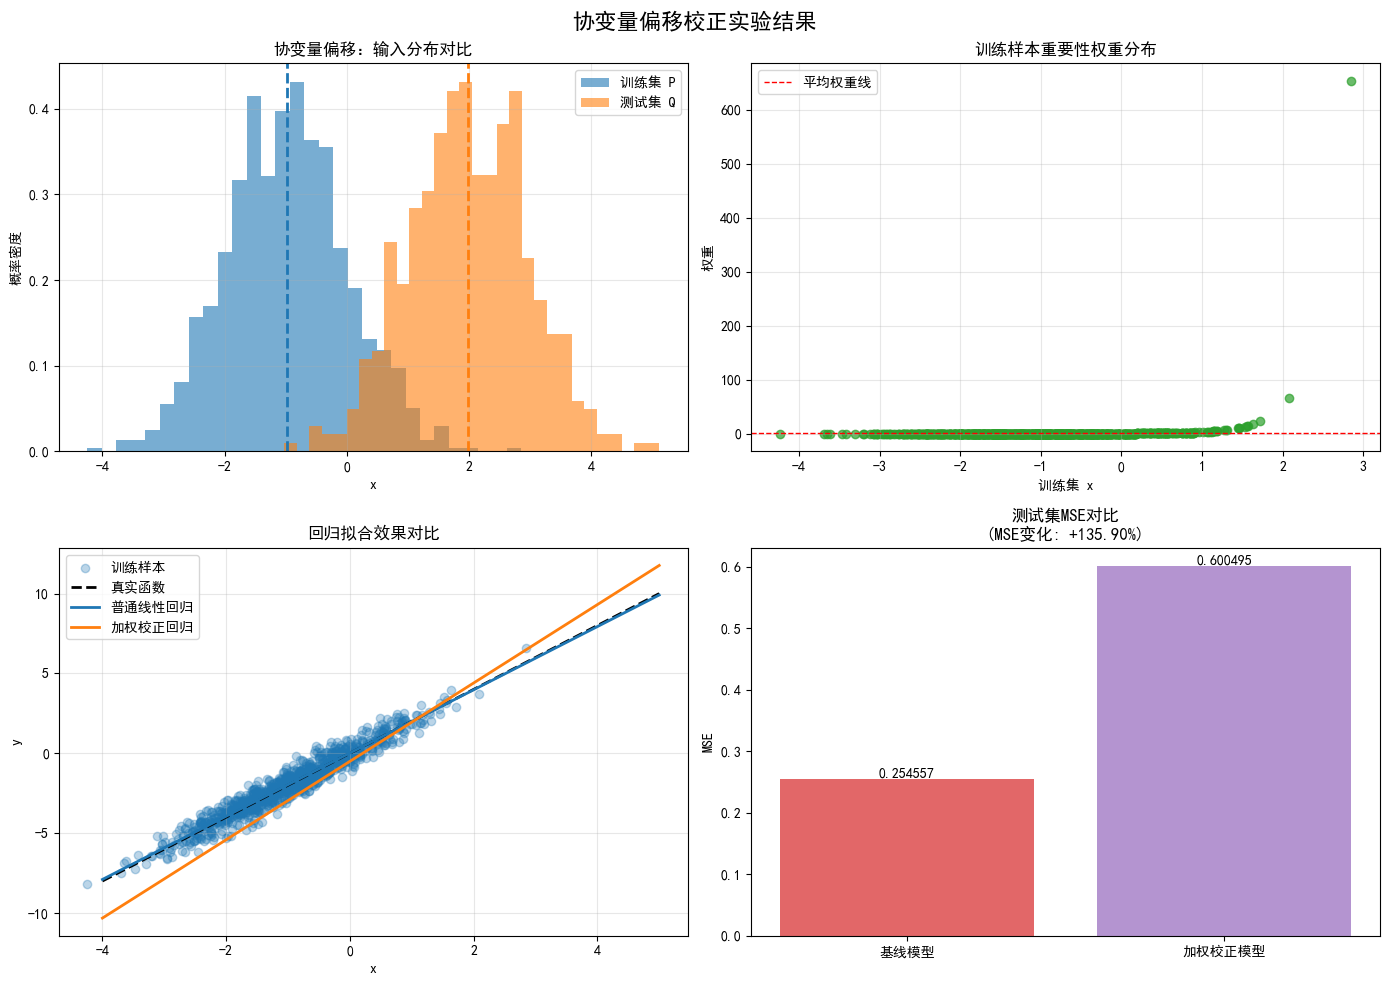

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

# 1. 人工数据集构造 
np.random.seed(42)
n_train = 1000
n_test = 500

# 训练集P：N(-1, 1)
x_train = np.random.normal(loc=-1, scale=1, size=n_train)
y_train = 2 * x_train + np.random.normal(loc=0, scale=0.5, size=n_train)

# 测试集Q：N(2, 1)，协变量偏移
x_test = np.random.normal(loc=2, scale=1, size=n_test)
y_test = 2 * x_test + np.random.normal(loc=0, scale=0.5, size=n_test)

# 2.基线模型训练与评估 
lr_base = LinearRegression()
lr_base.fit(x_train.reshape(-1, 1), y_train)
y_pred_base = lr_base.predict(x_test.reshape(-1, 1))
mse_base = mean_squared_error(y_test, y_pred_base)

print(f"基线模型参数: w={lr_base.coef_[0]:.4f}, b={lr_base.intercept_:.4f}")
print(f"测试集Q上的MSE（未修正）: {mse_base:.6f}")

# - 3. 偏移校正：估计样本权重 
x_all = np.concatenate([x_train, x_test]).reshape(-1, 1)
y_all = np.array([0] * n_train + [1] * n_test)

clf = LogisticRegression()
clf.fit(x_all, y_all)

p_test_given_x = clf.predict_proba(x_train.reshape(-1, 1))[:, 1]
p_train_given_x = 1 - p_test_given_x

weights = p_test_given_x / p_train_given_x
weights = weights / weights.mean()

print(f"重要性权重统计: min={weights.min():.4f}, max={weights.max():.4f}, mean={weights.mean():.4f}")

# 4. 加权模型训练与评估 
lr_weighted = LinearRegression()
lr_weighted.fit(x_train.reshape(-1, 1), y_train, sample_weight=weights)
y_pred_weighted = lr_weighted.predict(x_test.reshape(-1, 1))
mse_weighted = mean_squared_error(y_test, y_pred_weighted)

print(f"加权模型参数: w={lr_weighted.coef_[0]:.4f}, b={lr_weighted.intercept_:.4f}")
print(f"测试集Q上的MSE（修正后）: {mse_weighted:.6f}")
print(f"MSE相对变化: {(mse_weighted - mse_base) / mse_base * 100:+.2f}%")

#  
plt.figure(figsize=(14, 10))

# 训练/测试数据分布直方图
plt.subplot(2, 2, 1)
plt.hist(x_train, bins=30, alpha=0.6, density=True, label='训练集 P', color='#1f77b4')
plt.hist(x_test, bins=30, alpha=0.6, density=True, label='测试集 Q', color='#ff7f0e')
plt.axvline(x_train.mean(), color='#1f77b4', linestyle='--', linewidth=2)
plt.axvline(x_test.mean(), color='#ff7f0e', linestyle='--', linewidth=2)
plt.title('协变量偏移：输入分布对比', fontsize=12)
plt.xlabel('x')
plt.ylabel('概率密度')
plt.legend()
plt.grid(True, alpha=0.3)

# 重要性权重随训练样本x的分布
plt.subplot(2, 2, 2)
plt.scatter(x_train, weights, alpha=0.7, color='#2ca02c')
plt.axhline(y=1, color='red', linestyle='--', linewidth=1, label='平均权重线')
plt.title('训练样本重要性权重分布', fontsize=12)
plt.xlabel('训练集 x')
plt.ylabel('权重')
plt.legend()
plt.grid(True, alpha=0.3)

# 基线vs加权回归拟合线对比
plt.subplot(2, 2, 3)
x_range = np.linspace(-4, 5, 100)
y_true = 2 * x_range
y_base = lr_base.predict(x_range.reshape(-1, 1))
y_weighted = lr_weighted.predict(x_range.reshape(-1, 1))

plt.scatter(x_train, y_train, alpha=0.3, color='#1f77b4', label='训练样本')
plt.plot(x_range, y_true, 'k--', linewidth=2, label='真实函数')
plt.plot(x_range, y_base, linewidth=2, label='普通线性回归')
plt.plot(x_range, y_weighted, linewidth=2, label='加权校正回归')
plt.title('回归拟合效果对比', fontsize=12)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)

# 校正前后测试MSE对比柱状图
plt.subplot(2, 2, 4)
bars = plt.bar(['基线模型', '加权校正模型'], [mse_base, mse_weighted], 
               color=['#d62728', '#9467bd'], alpha=0.7)
plt.title(f'测试集MSE对比\n(MSE变化: {(mse_weighted - mse_base)/mse_base*100:+.2f}%)', fontsize=12)
plt.ylabel('MSE')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.6f}', ha='center', va='bottom')

plt.suptitle('协变量偏移校正实验结果', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()